<a href="https://colab.research.google.com/github/DhritiKothari/Handwriting-Analysis/blob/main/handwriting_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
from google.colab import drive
drive.mount('/content/drive')




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATASET_ROOT = "/content/drive/MyDrive/handwriting_dataset"
PREPROCESS_DIR = "/content/drive/MyDrive/preprocessed_images"

os.makedirs(PREPROCESS_DIR, exist_ok=True)


In [ ]:
all_images = []

for folder in os.listdir(DATASET_ROOT):
    folder_path = os.path.join(DATASET_ROOT, folder)
    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_images.append(os.path.join(folder_path, file))

print("Total images found:", len(all_images))
print(all_images[:5])



Total images found: 1340
['/content/drive/MyDrive/handwriting_dataset/388/h07-040.png', '/content/drive/MyDrive/handwriting_dataset/388/h07-044a.png', '/content/drive/MyDrive/handwriting_dataset/388/h07-051b.png', '/content/drive/MyDrive/handwriting_dataset/171/c04-160.png', '/content/drive/MyDrive/handwriting_dataset/171/c04-156.png']


In [ ]:
for img_path in all_images:
    img = cv2.imread(img_path)
    if img is None:
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    _, binary = cv2.threshold(
        gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    kernel = np.ones((3,3), np.uint8)
    cleaned = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

    folder = os.path.basename(os.path.dirname(img_path))
    filename = f"{folder}_{os.path.basename(img_path)}"

    cv2.imwrite(os.path.join(PREPROCESS_DIR, filename), cleaned)

print("✅ Preprocessing completed.")



✅ Preprocessing completed.


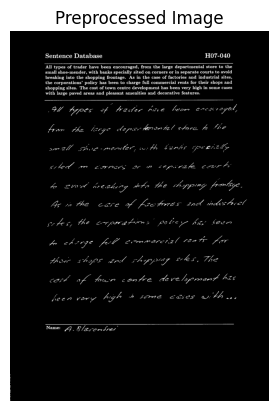

In [ ]:
test_img = os.listdir(PREPROCESS_DIR)[0]
img = cv2.imread(os.path.join(PREPROCESS_DIR, test_img), cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap="gray")
plt.title("Preprocessed Image")
plt.axis("off")
plt.show()


In [ ]:
import cv2
import numpy as np
import os

PREPROCESS_DIR = "/content/preprocessed_images"

def extract_slant(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return 0.0

    edges = cv2.Canny(img, 50, 150)

    lines = cv2.HoughLines(edges, 1, np.pi / 180, 120)
    if lines is None:
        return 0.0

    angles = []
    for line in lines[:30]:
        rho, theta = line[0]
        angle = (theta - np.pi / 2) * (180 / np.pi)
        angles.append(angle)

    return float(np.mean(angles))


In [ ]:
test_img = os.listdir(PREPROCESS_DIR)[0]
test_path = os.path.join(PREPROCESS_DIR, test_img)

slant_value = extract_slant(test_path)
print("Slant angle:", slant_value)


Slant angle: -0.03333360329270363


In [ ]:
slant_features = []

for img_name in os.listdir(PREPROCESS_DIR):
    img_path = os.path.join(PREPROCESS_DIR, img_name)
    slant = extract_slant(img_path)
    slant_features.append([img_name, slant])

print("Slant extracted for", len(slant_features), "images")


Slant extracted for 1340 images


In [ ]:
import pandas as pd

slant_df = pd.DataFrame(slant_features, columns=["image", "slant"])
slant_df.to_csv("/content/slant_features.csv", index=False)

print("Saved slant_features.csv")


Saved slant_features.csv


In [ ]:
import cv2
import numpy as np
import os

PREPROCESS_DIR = "/content/preprocessed_images"

def extract_baseline(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return 0.0

    ys, xs = np.where(img > 0)

    # Require sufficient text pixels
    if len(xs) < 200:
        return 0.0

    # Count pixels per column
    unique_x, counts = np.unique(xs, return_counts=True)

    # Keep columns with enough ink pixels (avoid gaps/margins)
    valid_columns = unique_x[counts > 5]

    if len(valid_columns) < 50:
        return 0.0

    # For each valid column, take lowest ink pixel
    baseline_x = []
    baseline_y = []

    for col in valid_columns:
        col_ys = ys[xs == col]
        baseline_x.append(col)
        baseline_y.append(np.max(col_ys))

    baseline_x = np.array(baseline_x)
    baseline_y = np.array(baseline_y)

    # Fit baseline line
    slope, _ = np.polyfit(baseline_x, baseline_y, 1)

    return float(slope)


In [ ]:
baseline_features = []

for img_name in os.listdir(PREPROCESS_DIR):
    img_path = os.path.join(PREPROCESS_DIR, img_name)
    baseline = extract_baseline(img_path)
    baseline_features.append([img_name, baseline])

print("Baseline extracted for", len(baseline_features), "images")



Baseline extracted for 1340 images


In [ ]:
import pandas as pd

baseline_df = pd.DataFrame(baseline_features, columns=["image", "baseline"])
baseline_df.to_csv("/content/baseline_features.csv", index=False)

print("Saved baseline_features.csv")


Saved baseline_features.csv


In [ ]:
import cv2
import numpy as np
import os

PREPROCESS_DIR = "/content/preprocessed_images"
def extract_word_spacing(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return 0.0

    # Ensure binary image
    _, binary = cv2.threshold(
        img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Horizontal dilation to merge letters into words
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (18, 3))
    dilated = cv2.dilate(binary, kernel, iterations=1)

    # Connected components on word blobs
    num_labels, _, stats, _ = cv2.connectedComponentsWithStats(dilated)

    boxes = []
    for i in range(1, num_labels):
        x, y, w, h, area = stats[i]
        if area > 300:  # filter noise, keep words
            boxes.append((x, w))

    if len(boxes) < 2:
        return 0.0

    # Sort words left to right
    boxes = sorted(boxes, key=lambda b: b[0])

    spacings = []
    for i in range(len(boxes) - 1):
        gap = boxes[i + 1][0] - (boxes[i][0] + boxes[i][1])
        if gap > 0:
            spacings.append(gap)

    return float(np.mean(spacings)) if spacings else 0.0



In [ ]:
test_img = os.listdir(PREPROCESS_DIR)[0]
test_path = os.path.join(PREPROCESS_DIR, test_img)

spacing_value = extract_word_spacing(test_path)
print("Average word spacing:", spacing_value)


Average word spacing: 3.0


In [ ]:
spacing_features = []

for img_name in os.listdir(PREPROCESS_DIR):
    img_path = os.path.join(PREPROCESS_DIR, img_name)
    spacing = extract_word_spacing(img_path)
    spacing_features.append([img_name, spacing])

print("Word spacing extracted for", len(spacing_features), "images")


Word spacing extracted for 1340 images


In [ ]:
import pandas as pd

spacing_df = pd.DataFrame(spacing_features, columns=["image", "spacing"])
spacing_df.to_csv("/content/spacing_features.csv", index=False)

print("Saved spacing_features.csv")


Saved spacing_features.csv


In [ ]:
import cv2
import numpy as np
import os

PREPROCESS_DIR = "/content/preprocessed_images"

def extract_stroke_thickness(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return 0.0

    # Convert to binary: handwriting = white, background = black
    _, binary = cv2.threshold(
        img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # Distance Transform
    dist = cv2.distanceTransform(binary, cv2.DIST_L2, 5)

    # Stroke thickness ≈ 2 × mean distance inside strokes
    thickness = 2 * np.mean(dist[dist > 0])

    return float(thickness)


In [ ]:
test_img = os.listdir(PREPROCESS_DIR)[0]
test_path = os.path.join(PREPROCESS_DIR, test_img)

stroke_value = extract_stroke_thickness(test_path)
print("Stroke thickness:", stroke_value)


Stroke thickness: 408.6268005371094


In [ ]:
stroke_features = []

for img_name in os.listdir(PREPROCESS_DIR):
    img_path = os.path.join(PREPROCESS_DIR, img_name)
    stroke = extract_stroke_thickness(img_path)
    stroke_features.append([img_name, stroke])

print("Stroke thickness extracted for", len(stroke_features), "images")


Stroke thickness extracted for 1340 images


In [ ]:
import pandas as pd

stroke_df = pd.DataFrame(stroke_features, columns=["image", "stroke"])
stroke_df.to_csv("/content/stroke_features.csv", index=False)

print("Saved stroke_features.csv")


Saved stroke_features.csv


In [ ]:
rows = []

for img_name in os.listdir(PREPROCESS_DIR):
    img_path = os.path.join(PREPROCESS_DIR, img_name)

    rows.append([
        img_name,
        extract_slant(img_path),
        extract_baseline(img_path),
        extract_word_spacing(img_path),
        extract_stroke_thickness(img_path)
    ])


In [ ]:
df = pd.DataFrame(rows, columns=[
    'image', 'slant', 'baseline', 'spacing', 'stroke'
])

df.fillna(0, inplace=True)
df.head()


,image,slant,baseline,spacing,stroke
0,d04-125.png,-0.033334,0.005488,3.0,408.626801
1,e04-095.png,-3.000000,-0.075378,179.5,330.853058
2,r03-035.png,0.066666,-0.077095,154.5,320.434326
3,p03-072.png,-6.166667,-0.040037,308.0,323.009705
4,d06-041.png,-3.266667,0.036349,237.0,310.954742


In [ ]:
slant_thr = df['slant'].median()
spacing_thr = df['spacing'].median()
stroke_thr = df['stroke'].median()
baseline_thr = df['baseline'].abs().median()


In [ ]:
def assign_personality(row):
    score = 0
    score += 1 if row['slant'] > slant_thr else -1
    score += 1 if row['spacing'] < spacing_thr else -1
    score += 1 if row['stroke'] > stroke_thr else -1
    score += 1 if abs(row['baseline']) < baseline_thr else -1
    return "Extrovert" if score > 0 else "Introvert"


In [ ]:
df['personality'] = df.apply(assign_personality, axis=1)
df['personality'].value_counts()


,count
personality,
Introvert,861
Extrovert,479


In [ ]:
X = df[['slant', 'baseline', 'spacing', 'stroke']]
y = df['personality']


In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)


In [ ]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [ ]:
y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))


[[ 95   1]
 [  0 172]]
              precision    recall  f1-score   support

   Extrovert       1.00      0.99      0.99        96
   Introvert       0.99      1.00      1.00       172

    accuracy                           1.00       268
   macro avg       1.00      0.99      1.00       268
weighted avg       1.00      1.00      1.00       268



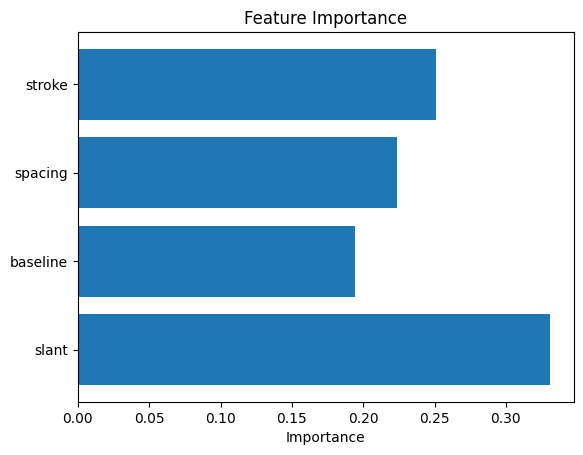

In [ ]:
importances = model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()


In [ ]:
X_all = df[['slant', 'baseline', 'spacing', 'stroke']]


In [ ]:
X_all_scaled = scaler.transform(X_all)


In [ ]:
y_pred_encoded = model.predict(X_all_scaled)


In [ ]:
y_pred_labels = le.inverse_transform(y_pred_encoded)


In [ ]:
df['predicted_personality'] = y_pred_labels


In [ ]:
df.to_csv("/content/drive/MyDrive/final_personality_predictions.csv", index=False)

print("✅ Final predictions saved")


✅ Final predictions saved


In [ ]:
df['predicted_personality'].value_counts()


,count
predicted_personality,
Introvert,862
Extrovert,478


In [ ]:
pd.crosstab(df['personality'], df['predicted_personality'])


predicted_personality,Extrovert,Introvert
personality,,
Extrovert,478,1
Introvert,0,861


In [ ]:
df[df['personality'] != df['predicted_personality']]


,image,slant,baseline,spacing,stroke,personality,predicted_personality
114,e06-026.png,-0.1,-0.096492,33.5,268.481598,Extrovert,Introvert


In [ ]:
importances = model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

importance_df


,feature,importance
0,slant,0.331057
3,stroke,0.251096
2,spacing,0.223496
1,baseline,0.194351


In [ ]:
def explain_prediction(row):
    explanation = []

    if row['slant'] > slant_thr:
        explanation.append("Right-slanted writing indicates emotional expressiveness (Extrovert)")
    else:
        explanation.append("Vertical/left slant indicates reserved emotional expression (Introvert)")

    if row['spacing'] < spacing_thr:
        explanation.append("Narrow word spacing suggests sociability (Extrovert)")
    else:
        explanation.append("Wide word spacing suggests preference for personal space (Introvert)")

    if row['stroke'] > stroke_thr:
        explanation.append("Thicker strokes indicate higher energy and confidence (Extrovert)")
    else:
        explanation.append("Thinner strokes indicate controlled or cautious writing (Introvert)")

    if abs(row['baseline']) < baseline_thr:
        explanation.append("Stable baseline suggests emotional stability")
    else:
        explanation.append("Unstable baseline suggests emotional variability")

    return explanation


In [ ]:
sample = df.iloc[0]

print("Image:", sample['image'])
print("Predicted Personality:", sample['predicted_personality'])

for reason in explain_prediction(sample):
    print("-", reason)


Image: d04-125.png
Predicted Personality: Extrovert
- Right-slanted writing indicates emotional expressiveness (Extrovert)
- Narrow word spacing suggests sociability (Extrovert)
- Thicker strokes indicate higher energy and confidence (Extrovert)
- Stable baseline suggests emotional stability


In [ ]:
df['decision_basis'] = df.apply(
    lambda row: "; ".join(explain_prediction(row)),
    axis=1
)


In [ ]:
df[['image', 'predicted_personality', 'decision_basis']].to_csv(
    "/content/drive/MyDrive/handwriting_explainable_labels.csv",
    index=False
)

print("✅ Explainable labeled dataset saved")



✅ Explainable labeled dataset saved
